In [5]:
#General Packages
import pandas as pd
import torch
import torch.nn.functional as F
import ast
import scipy.stats as stats
import os

#Statistical tests
import statsmodels.formula.api as smf

#Plot
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

In [6]:
directory = '../results/'

df = pd.concat(
    [pd.read_csv(os.path.join(directory, f)) for f in os.listdir(directory) if f.endswith('.csv')],
    ignore_index=True
).drop_duplicates()

In [7]:
nan_rows = df[df.isna().any(axis=1)]
nan_rows.head(5)

,model,attack,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,attack_successful,psnr_score,ssim_score,ergas_score,adversarial_image_path,original_probs,adversarial_probs,dataset_index
0,mobilenet_imagenet20_adv,fgsm,0,5,0,0,NaN,False,84.390099,0.999988,8.877092e+05,results/adversarial_images/adv_fgsm_src0_tgt5_...,"[1.0, 4.303542244787906e-11, 1.507875768691491...","[0.9999971389770508, 7.97165089494456e-09, 2.4...",0
1,mobilenet_imagenet20_adv,fgsm,0,7,0,0,NaN,False,84.892670,0.999990,1.451800e+06,results/adversarial_images/adv_fgsm_src0_tgt7_...,"[0.6130468249320984, 8.343882655026391e-06, 4....","[0.8348283171653748, 9.7318843472749e-05, 3.15...",1
2,mobilenet_imagenet20_adv,fgsm,0,10,0,0,NaN,False,84.441742,0.999988,1.249557e+06,results/adversarial_images/adv_fgsm_src0_tgt10...,"[1.0, 2.8384542979931204e-13, 2.49330483830748...","[1.0, 1.5219685234324487e-10, 3.25161902611781...",2
3,mobilenet_imagenet20_adv,fgsm,0,5,0,0,NaN,False,84.437363,0.999990,1.529932e+06,results/adversarial_images/adv_fgsm_src0_tgt5_...,"[1.0, 5.249876922075458e-12, 2.592430122568684...","[1.0, 2.1098221780757598e-10, 8.6023410617031e...",3
4,mobilenet_imagenet20_adv,fgsm,0,3,0,0,NaN,False,84.361328,0.999989,8.902008e+05,results/adversarial_images/adv_fgsm_src0_tgt3_...,"[0.9999822378158569, 2.076743665924141e-09, 7....","[0.9985185265541077, 1.3613777127829962e-07, 6...",4


In [8]:
df.loc[df['first_success_iter'].isna(), 'attack_successful'] = False
df['first_success_iter'] = df['first_success_iter'].fillna(1000000)

In [9]:
model_counts = df['model'].value_counts()
print(model_counts)

model
mobilenet_imagenet20_adv       11808
mobilenet_imagenet20           11808
mobilenet_imagenet20_robust    11808
resnet_imagenet20_adv          11808
resnet_imagenet20              11808
resnet_imagenet20_robust       11808
swin_imagenet20_adv            11808
swin_imagenet20                11808
swin_imagenet20_robust         11808
Name: count, dtype: int64


In [10]:
df_mobilenet = df[df['model'] == 'mobilenet_imagenet20'].copy()
df_resnet    = df[df['model'] == 'resnet_imagenet20'].copy()
df_swin      = df[df['model'] == 'swin_imagenet20'].copy()

In [11]:
df_models = pd.concat([df_mobilenet, df_resnet, df_swin], ignore_index=True)

In [12]:
df_fgsm = df_models[df_models['attack'] == 'fgsm'].copy()
df_cw    = df_models[df_models['attack'] == 'cw'].copy()
df_pgd      = df_models[df_models['attack'] == 'pgd'].copy()

In [13]:
df_attack = pd.concat([df_fgsm, df_cw, df_pgd], ignore_index=True)

### Attacks general statistics

In [14]:
df_fgsm.describe()

,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,psnr_score,ssim_score,ergas_score,dataset_index
count,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,1.180800e+04,1.180800e+04,11808.000000
mean,9.532774,9.451897,9.564194,9.610857,31086.832402,85.846883,9.999964e-01,7.900478e+05,1994.761179
std,5.787412,5.786076,5.801444,5.774692,173541.876340,0.184848,3.092910e-07,5.426265e+05,1151.774203
min,0.000000,0.000000,0.000000,0.000000,0.000000,84.533096,9.999943e-01,5.670353e-01,0.000000
25%,5.000000,4.000000,5.000000,5.000000,2.000000,85.764790,9.999962e-01,1.004288e+01,999.750000
50%,10.000000,9.000000,10.000000,10.000000,4.000000,85.889690,9.999964e-01,1.050984e+06,1995.500000
75%,15.000000,14.000000,15.000000,15.000000,7.000000,85.958321,9.999967e-01,1.286090e+06,2991.250000
max,19.000000,19.000000,19.000000,19.000000,1000000.000000,86.571693,9.999971e-01,1.513161e+06,3991.000000


In [15]:
df_pgd.describe()

,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,psnr_score,ssim_score,ergas_score,dataset_index
count,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,1.180800e+04,1.180800e+04,11808.000000
mean,9.532774,9.486111,9.564194,9.433012,23825.749153,91.256196,9.999990e-01,4.347433e+05,1994.761179
std,5.787412,5.751110,5.801444,5.735606,152419.578077,1.592932,5.794501e-07,3.121637e+05,1151.774203
min,0.000000,0.000000,0.000000,0.000000,0.000000,85.923912,9.999962e-01,2.303667e-01,0.000000
25%,5.000000,5.000000,5.000000,4.000000,15.000000,90.141542,9.999985e-01,5.514528e+00,999.750000
50%,10.000000,9.000000,10.000000,9.000000,25.000000,91.347908,9.999992e-01,5.265132e+05,1995.500000
75%,15.000000,14.000000,15.000000,14.000000,40.000000,92.504864,9.999993e-01,6.703962e+05,2991.250000
max,19.000000,19.000000,19.000000,19.000000,1000000.000000,94.968498,9.999998e-01,1.242944e+06,3991.000000


In [16]:
df_cw.describe()

,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,psnr_score,ssim_score,ergas_score,dataset_index
count,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,1.180800e+04,11808.000000
mean,9.532774,9.448340,9.564194,9.887873,1611.929455,75.263213,0.999954,2.653200e+06,1994.761179
std,5.787412,5.737463,5.801444,5.693459,40082.619005,2.051316,0.000021,1.929789e+06,1151.774203
min,0.000000,0.000000,0.000000,0.000000,1.000000,68.699532,0.999802,7.124950e-01,0.000000
25%,5.000000,5.000000,5.000000,5.000000,2.000000,73.943089,0.999944,3.938079e+01,999.750000
50%,10.000000,9.000000,10.000000,10.000000,3.000000,75.221806,0.999957,3.136198e+06,1995.500000
75%,15.000000,14.000000,15.000000,15.000000,3.000000,76.486044,0.999968,4.109907e+06,2991.250000
max,19.000000,19.000000,19.000000,19.000000,1000000.000000,88.749992,0.999998,8.026403e+06,3991.000000


In [17]:
df_attack = df_attack[df_attack["first_success_iter"] != 1000000]
df_attack.groupby('attack')['first_success_iter'].mean()

attack
cw       2.855458
fgsm     6.408269
pgd     29.014141
Name: first_success_iter, dtype: float64

### Successrate Attacktypes

In [ ]:
# Calculate success rates
success_rates = df_mobilenet.groupby('attack')['attack_successful'].mean()
counts = df_mobilenet.groupby('attack')['attack_successful'].sum()
totals = df_mobilenet.groupby('attack')['attack_successful'].count()

# Compute confidence intervals
ci_df_mobilenet = pd.DataFrame(columns=["success_rate", "n", "ci_low", "ci_high"])

for attack in success_rates.index:
    x = counts[attack]
    n = totals[attack]
    rate = success_rates[attack]
    ci_low, ci_high = proportion_confint(count=x, nobs=n, alpha=0.05, method='normal')
    ci_df_mobilenet.loc[attack] = [rate, n, ci_low, ci_high]

# Display the result
print(ci_df_mobilenet)

      success_rate       n    ci_low   ci_high
cw        0.474593  3936.0  0.458993  0.490194
fgsm      0.908537  3936.0  0.899531  0.917542
pgd       0.994411  3936.0  0.992081  0.996740


In [ ]:
# Calculate success rates
success_rates = df_resnet.groupby('attack')['attack_successful'].mean()
counts = df_resnet.groupby('attack')['attack_successful'].sum()
totals = df_resnet.groupby('attack')['attack_successful'].count()

# Compute confidence intervals
ci_df_resnet = pd.DataFrame(columns=["success_rate", "n", "ci_low", "ci_high"])

for attack in success_rates.index:
    x = counts[attack]
    n = totals[attack]
    rate = success_rates[attack]
    ci_low, ci_high = proportion_confint(count=x, nobs=n, alpha=0.05, method='normal')  
    ci_df_resnet.loc[attack] = [rate, n, ci_low, ci_high]

# Display the result
print(ci_df_resnet)

      success_rate       n    ci_low   ci_high
cw        0.140752  3936.0  0.129888  0.151616
fgsm      0.688516  3936.0  0.674049  0.702984
pgd       0.975102  3936.0  0.970234  0.979969


In [ ]:
# Calculate success rates
success_rates = df_swin.groupby('attack')['attack_successful'].mean()
counts = df_swin.groupby('attack')['attack_successful'].sum()
totals = df_swin.groupby('attack')['attack_successful'].count()

# Compute confidence intervals
ci_df_swin = pd.DataFrame(columns=["success_rate", "n", "ci_low", "ci_high"])

for attack in success_rates.index:
    x = counts[attack]
    n = totals[attack]
    rate = success_rates[attack]
    ci_low, ci_high = proportion_confint(count=x, nobs=n, alpha=0.05, method='normal')  
    ci_df_swin.loc[attack] = [rate, n, ci_low, ci_high]

# Display the result
print(ci_df_swin)

      success_rate       n    ci_low   ci_high
cw        0.670732  3936.0  0.656050  0.685413
fgsm      0.835874  3936.0  0.824303  0.847445
pgd       0.958587  3936.0  0.952363  0.964812


In [ ]:
# Calculate success rates
success_rates = df_models.groupby('attack')['attack_successful'].mean()
counts = df_models.groupby('attack')['attack_successful'].sum()
totals = df_models.groupby('attack')['attack_successful'].count()

# Compute confidence intervals
ci_df = pd.DataFrame(columns=["success_rate", "n", "ci_low", "ci_high"])

for attack in success_rates.index:
    x = counts[attack]
    n = totals[attack]
    rate = success_rates[attack]
    ci_low, ci_high = proportion_confint(count=x, nobs=n, alpha=0.05, method='normal')  
    ci_df.loc[attack] = [rate, n, ci_low, ci_high]

# Display the result
ci_df

,success_rate,n,ci_low,ci_high
cw,0.428692,11808.0,0.419766,0.437619
fgsm,0.810976,11808.0,0.803914,0.818038
pgd,0.976033,11808.0,0.973275,0.978792


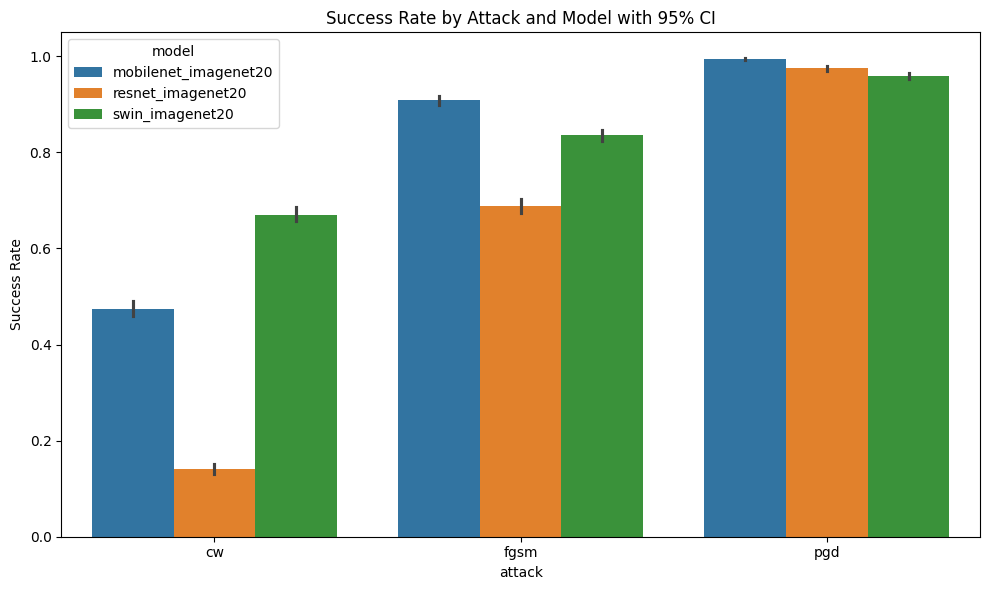

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_models,
    x="attack",
    y="attack_successful",
    hue="model",
    errorbar=('ci', 95),
    estimator=lambda x: x.mean() 
)

plt.title("Success Rate by Attack and Model with 95% CI")
plt.ylabel("Success Rate")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


# Stastistical tests

### PSNR

In [268]:
success_rates = df_models.groupby('attack')['psnr_score'].mean()
print(success_rates)

attack
cw      75.263213
fgsm    85.846883
pgd     91.256196
Name: psnr_score, dtype: float64


In [ ]:
model = smf.mixedlm(
    "psnr_score ~ model * attack",    
    df_models,
    groups="dataset_index"                 
)
result = model.fit()

# Print the summary
print(result.summary())


                        Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          psnr_score 
No. Observations:            35424            Method:                      REML       
No. Groups:                  3936             Scale:                       1.4203     
Min. group size:             9                Log-Likelihood:              -58774.3681
Max. group size:             9                Converged:                   Yes        
Mean group size:             9.0                                                      
--------------------------------------------------------------------------------------
                                          Coef.  Std.Err.    z     P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------
Intercept                                 75.583    0.021 3570.888 0.000 75.541 75.624
model[T.resnet_imagenet20]                -1.356    0.027  -50.470 0

In [272]:
total_var = df_models["psnr_score"].var()
model_scale = result.scale
proportion_unexplained = model_scale / total_var
proportion_unexplained

0.03062458699914478

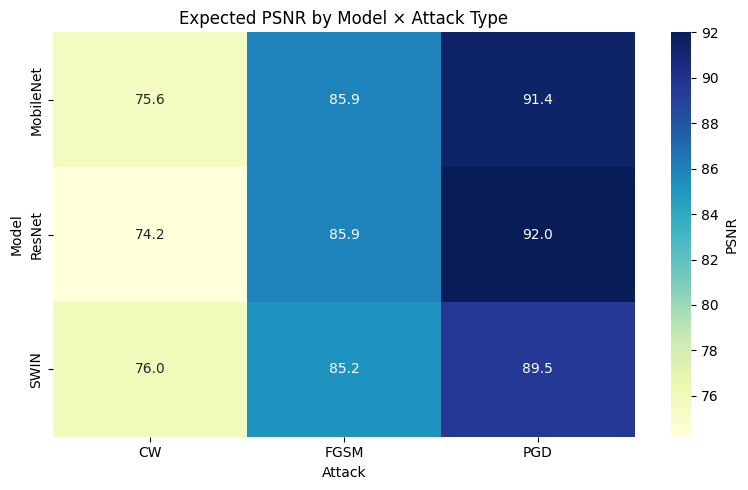

In [ ]:
data = [
    [75.6, 85.9, 91.4],  # MobileNet
    [74.2, 85.9, 92.0],  # ResNet
    [76.0, 85.2, 89.5],  # SWIN
]

# Row and column labels
models = ['MobileNet', 'ResNet', 'SWIN']
attacks = ['CW', 'FGSM', 'PGD']

# Create a DataFrame
df = pd.DataFrame(data, index=models, columns=attacks)

#Generate heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'PSNR'})
plt.title('Expected PSNR by Model × Attack Type')
plt.ylabel('Model')
plt.xlabel('Attack')
plt.tight_layout()
plt.show()


### ERGAS

In [274]:
success_rates = df_models.groupby('attack')['ergas_score'].mean()
print(success_rates)

attack
cw      2.653200e+06
fgsm    7.900478e+05
pgd     4.347433e+05
Name: ergas_score, dtype: float64


In [ ]:
model = smf.mixedlm(
    "ergas_score ~ model * attack",     
    df_models,
    groups="dataset_index"                 
)
result = model.fit()

# Print the summary
print(result.summary())


                                    Mixed Linear Model Regression Results
Model:                            MixedLM                Dependent Variable:                ergas_score      
No. Observations:                 35424                  Method:                            REML             
No. Groups:                       3936                   Scale:                             621623085254.4222
Min. group size:                  9                      Log-Likelihood:                    -535971.4440     
Max. group size:                  9                      Converged:                         Yes              
Mean group size:                  9.0                                                                        
-------------------------------------------------------------------------------------------------------------
                                               Coef.        Std.Err.    z     P>|z|    [0.025       0.975]   
----------------------------------------------

In [275]:
total_var = df_models["ergas_score"].var()
model_scale = result.scale
proportion_unexplained = 621623085254.4215 / total_var
proportion_unexplained

0.26811315551812787

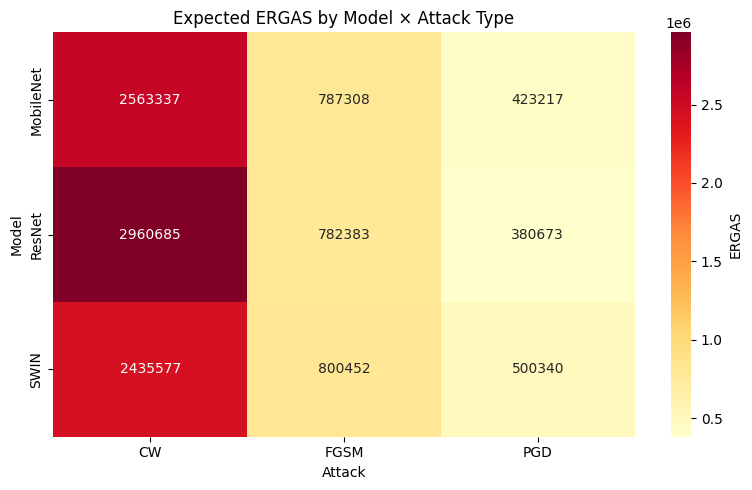

In [ ]:
# Intercept
base = 2563337.320

# ERGAS values 
data = [
    [base,  # MobileNet + CW (baseline)
     base + -1776029.176,  # MobileNet + FGSM
     base + -2140119.934],  # MobileNet + PGD

    [base + 397347.726,  # ResNet + CW
     base + 397347.726 + -1776029.176 + -402272.931,  # ResNet + FGSM
     base + 397347.726 + -2140119.934 + -439892.219],  # ResNet + PGD

    [base + -127760.401,  # SWIN + CW
     base + -127760.401 + -1776029.176 + 140904.526,  # SWIN + FGSM
     base + -127760.401 + -2140119.934 + 204882.535],  # SWIN + PGD
]

# Row and column labels
models = ['MobileNet', 'ResNet', 'SWIN']
attacks = ['CW', 'FGSM', 'PGD']

# Create DataFrame
df = pd.DataFrame(data, index=models, columns=attacks)

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={'label': 'ERGAS'})
plt.title('Expected ERGAS by Model × Attack Type')
plt.ylabel('Model')
plt.xlabel('Attack')
plt.tight_layout()
plt.show()


### KL divergence in probability distribution

In [ ]:
df_models["original_probs"] = df_models["original_probs"].apply(ast.literal_eval)
df_models["adversarial_probs"] = df_models["adversarial_probs"].apply(ast.literal_eval)

In [162]:
def kl_divergence(p, q):
    # Convert to tensors
    p = torch.tensor(p, dtype=torch.float32)
    q = torch.tensor(q, dtype=torch.float32)

    # Add small epsilon to avoid log(0)
    epsilon = 1e-8
    p = p + epsilon
    q = q + epsilon

    return F.kl_div(q.log(), p, reduction="sum").item()  

In [ ]:
df_models["kl_divergence"] = df_models.apply(lambda row: kl_divergence(row["original_probs"], row["adversarial_probs"]), axis=1)


In [ ]:
print(df_models.groupby("attack")["kl_divergence"].mean())

attack
cw      2.115369
fgsm    3.794806
pgd     7.560499
Name: kl_divergence, dtype: float64


In [ ]:
print(df_models[["kl_divergence", "psnr_score"]].corr())

               kl_divergence  psnr_score
kl_divergence       1.000000    0.446686
psnr_score          0.446686    1.000000


In [ ]:
model = smf.mixedlm("kl_divergence ~ model * attack", data=df_models, groups=df_models["dataset_index"])
result = model.fit()

print(result.summary())

                        Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         kl_divergence
No. Observations:           35424           Method:                     REML         
No. Groups:                 3936            Scale:                      9.3841       
Min. group size:            9               Log-Likelihood:             -92080.8216  
Max. group size:            9               Converged:                  Yes          
Mean group size:            9.0                                                      
-------------------------------------------------------------------------------------
                                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                  2.101    0.054  38.974 0.000  1.996  2.207
model[T.resnet_imagenet20]                -1.341    0.069 -19.425 0.000 -1.477

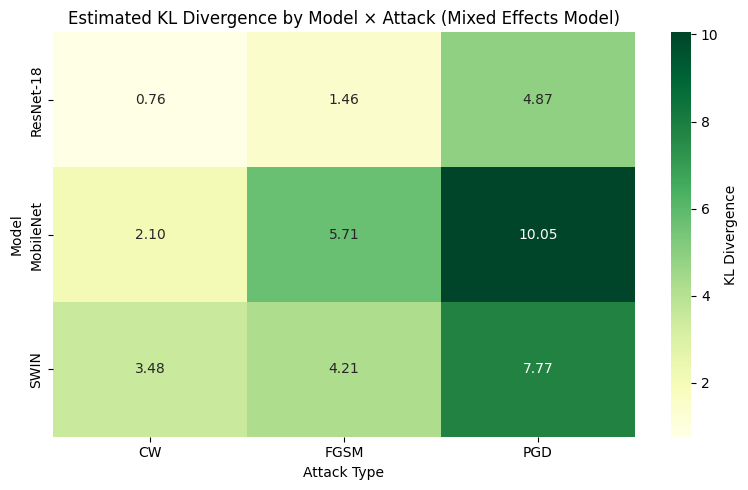

In [ ]:
# Reconstruct KL divergence values 
intercept = 2.101
coeffs = {
    "ResNet-18": {
        "FGSM": intercept + (-1.341) + 3.607 + (-2.905),
        "PGD":  intercept + (-1.341) + 7.947 + (-3.842),
        "CW":   intercept + (-1.341)
    },
    "MobileNet": {
        "FGSM": intercept + 3.607,
        "PGD":  intercept + 7.947,
        "CW":   intercept
    },
    "SWIN": {
        "FGSM": intercept + 1.383 + 3.607 + (-2.878),
        "PGD":  intercept + 1.383 + 7.947 + (-3.663),
        "CW":   intercept + 1.383
    }
}

# Convert to DataFrame
df = pd.DataFrame(coeffs).T
df = df[["CW", "FGSM", "PGD"]]

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df, annot=True, fmt=".2f", cmap="YlGn", cbar_kws={'label': 'KL Divergence'})
plt.title("Estimated KL Divergence by Model × Attack (Mixed Effects Model)")
plt.xlabel("Attack Type")
plt.ylabel("Model")
plt.tight_layout()
plt.show()
